# **Loss Function Testing**

This notebook tests different loss functions for the XPM identity operator training:
- `loss_function`: Basic MSE loss on intensities
- `hg_loss_function`: MSE loss on HG coefficients
- `normalized_hg_loss_function`: MSE loss on normalized HG coefficients


## Setup and Imports


In [1]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
# ml imports
import torch
import torch.nn.functional as F
from tqdm import tqdm

# import module
from nlse import *

Using device: cpu


## Configuration Parameters

In [2]:
num_modes = 6  # Number of HG modes for training (batch size)

# Simulation parameters
Lz = 1e-3          # Propagation length
Nz = 100          # Number of z steps
Lt = 14         # Time window
Nt = 2048        # Number of time points
N_modes = 500      # Total HG basis size
dz = Lz / Nz
dt = Lt / Nt

# Medium parameters
beta2_j = -10.0
beta2_k = -10.0
gamma_j = 1.0
gamma_k = 1.0

# Pulse parameters
tau = 0.1

# Training parameters
amplitude_downscale = 0.1
mask_percent = 0.8
m = 8              # Number of penalty iterations
w_mse = 1e4	        # MSE loss weight
w_pen = 1e3        # Penalty loss weight
lr = 0.1          # Learning rate
N_train = 250      # Number of training iterations (small for quick testing)


## Define Useful Functions

In [3]:
def time_to_trunc_hg(A, hg_basis, dt, num_modes):
    return torch.stack([time_to_hg(A[i], hg_basis[:num_modes, :], dt) for i in range(num_modes)])  # shape: (B, B)

# define error function
def get_hg_err(result, target, hg_basis):
    result_hg = time_to_trunc_hg(result, hg_basis, dt, num_modes) # here dt and num_modes are globally defined
    target_hg = time_to_trunc_hg(target, hg_basis, dt, num_modes) # here dt and num_modes are globally defined
    return torch.sum(torch.abs(result_hg - target_hg)**2)

def get_mse_err(result, target):
    return F.mse_loss(torch.abs(result)**2, torch.abs(target)**2)

def evaluate(theta, hg_basis, dt, x_test, y_test):
    Ain_k = hg_to_time(theta.clone().detach(), hg_basis)
    A_j_evolution, A_k_evolution = split_step_fourier_xpm_batch(x_test, Ain_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    target = y_test # (B, Nt)
    result = A_j_evolution[:, :, -1] # (B, Nt)
    
    mse_err = get_mse_err(result, target)
    hg_err = get_hg_err(result, target, hg_basis)
    
    return mse_err, hg_err

## Setup Training Data and Basis


Precomputed 500 HG basis functions on grid of 2048 points on device cpu
Precomputed 6 HG basis functions on grid of 2048 points on device cpu


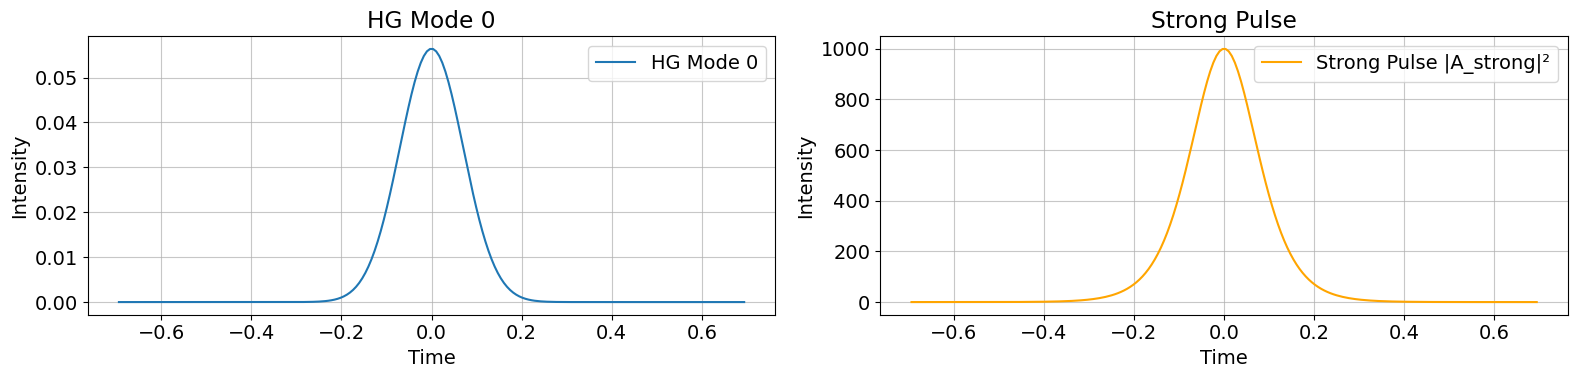

In [4]:
# Create time grid
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32, device=device)

# Define HG basis
hg_basis = get_hg_basis(N_modes, t, tau)

# Get batch of pulses (using num_modes)
B = num_modes
x = get_hg_basis(B, t, tau) * amplitude_downscale  # inputs
y = x.clone().detach()  # labels (identity operator)

# Define input strong pulse (soliton)
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    return Ain_k

A_strong = strong_soliton(t, beta2_k, gamma_k, tau)
A_strong_hg = time_to_hg(A_strong, hg_basis, dt)

# Define penalty mask
penalty = torch.zeros_like(t, device=device)
penalty[:int(Nt/2 - Nt*mask_percent/2)] = 1
penalty[int(Nt/2 + Nt*mask_percent/2):] = 1
mask = 1 - penalty
iters = np.linspace(0, Nz-1, m).astype(int)


""" Plotting """
# plot a single mode and strong pulse side by side
mode_num = 0
plot_percent = 0.1

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
intensity = torch.abs(x[mode_num]).cpu().numpy()**2

Nt_total = len(t)
center = Nt_total // 2
half_width = int(Nt_total * plot_percent / 2)
start = max(center - half_width, 0)
end = min(center + half_width, Nt_total)

# Plot HG mode
axes[0].plot(t[start:end].cpu().numpy(), intensity[start:end], label=f'HG Mode 0')
axes[0].set_title(f'HG Mode {mode_num}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Intensity')
axes[0].grid(True, alpha=0.7)
axes[0].legend()

# Plot strong pulse
A_strong_intensity = torch.abs(A_strong).cpu().numpy()**2
axes[1].plot(t[start:end].cpu().numpy(), A_strong_intensity[start:end], label='Strong Pulse |A_strong|²', color='orange')
axes[1].set_title('Strong Pulse')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Intensity')
axes[1].grid(True, alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


## Define Loss Functions


In [5]:
# Define target HG coefficients (identity matrix)
y_hg = torch.eye(B, dtype=torch.float32, device=device) * amplitude_downscale
hg_basis_B = hg_basis[:B, :]

# 1. Basic loss function (from train_xpm_identity.py)
def loss_function(A_j_evolution, A_k_evolution):
    """Basic MSE loss on intensities."""
    # MSE loss
    mse_loss = F.mse_loss(torch.abs(A_j_evolution[:, :, -1])**2, torch.abs(y)**2)
    
    pen_loss = 0.0
    zeros = torch.zeros(B, Nt, dtype=torch.float32, device=device)
    # Penalization loss - to enforce none of the waves to stray outside the simulation bounds
    for i in iters:
        pen_loss = pen_loss + F.mse_loss(torch.abs(A_k_evolution[:, :, i]*penalty)**2, zeros)
    
    return w_mse * mse_loss, w_pen * pen_loss

# 2. HG coefficient loss function
def hg_loss_function(A_j_evolution, A_k_evolution):
    """MSE loss on HG coefficients. Optionally plot a histogram comparison."""
    final_j = A_j_evolution[:, :, -1]  # shape: (B, Nt)
    # Compute HG coefficients for each signal in the batch
    final_j_hg = torch.stack([time_to_hg(final_j[i], hg_basis_B, dt) for i in range(B)])  # shape: (B, B)
    # Calculate the MSE loss between the final HG coefficients and the target HG coefficients
    mse_loss = F.mse_loss(torch.abs(final_j_hg)**2, torch.abs(y_hg)**2)
    
    pen_loss = 0.0
    zeros = torch.zeros(B, Nt, dtype=torch.float32, device=device)
    # Penalization loss - to enforce none of the waves to stray outside the simulation bounds
    for i in iters:
        pen_loss = pen_loss + F.mse_loss(torch.abs(A_k_evolution[:, :, i]*penalty)**2, zeros)
        
    return w_mse * mse_loss, w_pen * pen_loss


# 3. Normalized HG coefficient loss function
def normalized_hg_loss_function(A_j_evolution, A_k_evolution):
    """MSE loss on normalized HG coefficients."""
    final_j = A_j_evolution[:, :, -1]  # shape: (B, Nt)
    # Compute HG coefficients for each signal in the batch
    final_j_hg = torch.stack([time_to_hg(final_j[i], hg_basis_B, dt) for i in range(B)])  # shape: (B, B)
    # Add epsilon for numerical stability during normalization
    eps = 1e-10
    final_j_hg_normalized = final_j_hg / (torch.norm(final_j_hg, dim=1, keepdim=True) + eps) * amplitude_downscale
    # Calculate the MSE loss between the final HG coefficients and the target HG coefficients
    mse_loss = F.mse_loss(final_j_hg_normalized, y_hg)

    pen_loss = 0.0
    zeros = torch.zeros(B, Nt, dtype=torch.float32, device=device)
    # Penalization loss - to enforce none of the waves to stray outside the simulation bounds
    for i in iters:
        pen_loss = pen_loss + F.mse_loss(torch.abs(A_k_evolution[:, :, i]*penalty)**2, zeros)
        
    return w_mse * mse_loss, w_pen * pen_loss


## Run Training


In [6]:
loss_fn = hg_loss_function

In [7]:
# Initialize theta
theta = torch.nn.Parameter(A_strong_hg.clone().detach().requires_grad_(True))
optimizer = torch.optim.Adam([theta], lr=lr)

losses_mse = []
losses_pen = []
losses_total = []
mse_errs = []
hg_errs = []

# Training loop
for i in tqdm(range(N_train), desc="Training"):
    optimizer.zero_grad()
    Ain_k = hg_to_time(theta, hg_basis)
    A_j_evolution, A_k_evolution = split_step_fourier_xpm_batch(x, Ain_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)
    loss_mse, loss_pen = loss_fn(A_j_evolution, A_k_evolution)
    loss = loss_mse + loss_pen
    loss.backward()
    optimizer.step()

    losses_mse.append(loss_mse.item())
    losses_pen.append(loss_pen.item())
    losses_total.append(loss.item())
    
    # evaluate
    with torch.no_grad():
        mse_err, hg_err = evaluate(theta, hg_basis, hg_basis_B, x, y)
    # Save error values to lists
    mse_errs.append(mse_err.item())
    hg_errs.append(hg_err.item())

Training: 100%|██████████| 250/250 [09:06<00:00,  2.18s/it]


## Analyze Results

Final Loss: 0.000339 (MSE: 0.000339, Pen: 0.000000)


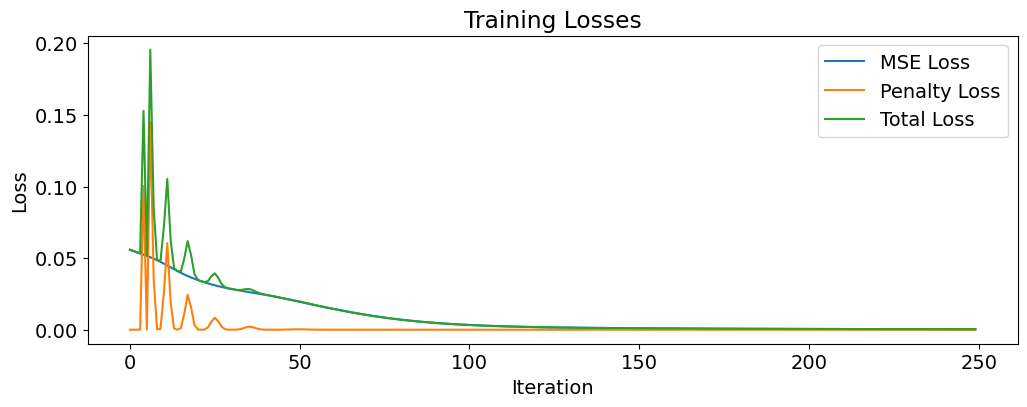

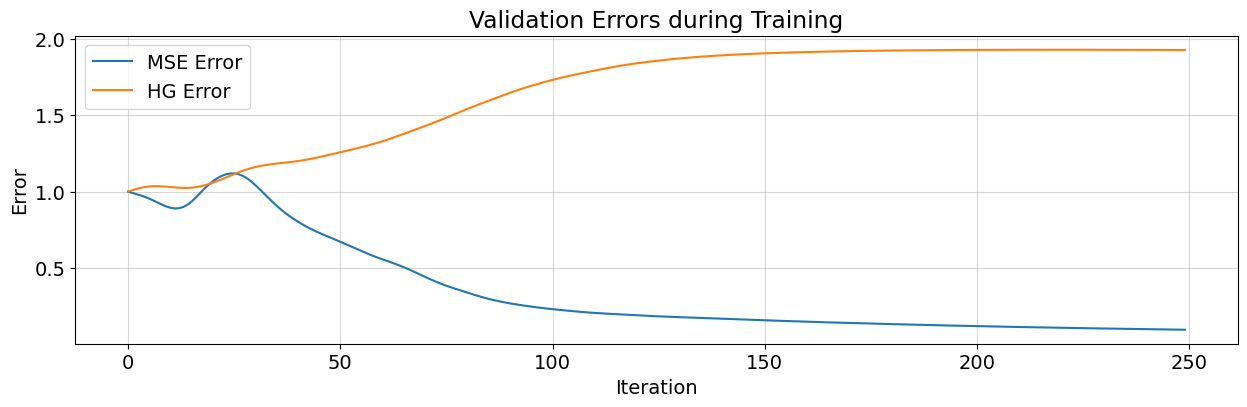

In [8]:
print(f"Final Loss: {losses_total[-1]:.6f} (MSE: {losses_mse[-1]:.6f}, Pen: {losses_pen[-1]:.6f})")

# Plot losses
plt.figure(figsize=(12,4))
plt.plot(losses_mse, label="MSE Loss")
plt.plot(losses_pen, label="Penalty Loss")
plt.plot(losses_total, label="Total Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

# normalize errs
mse0 = mse_errs[0]; mse_errs = [el / mse0 for el in mse_errs]
hg0 = hg_errs[0]; hg_errs = [el / hg0 for el in hg_errs]

plt.figure(figsize=(15,4))
plt.plot(mse_errs, label='MSE Error')
plt.plot(hg_errs, label='HG Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Validation Errors during Training')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


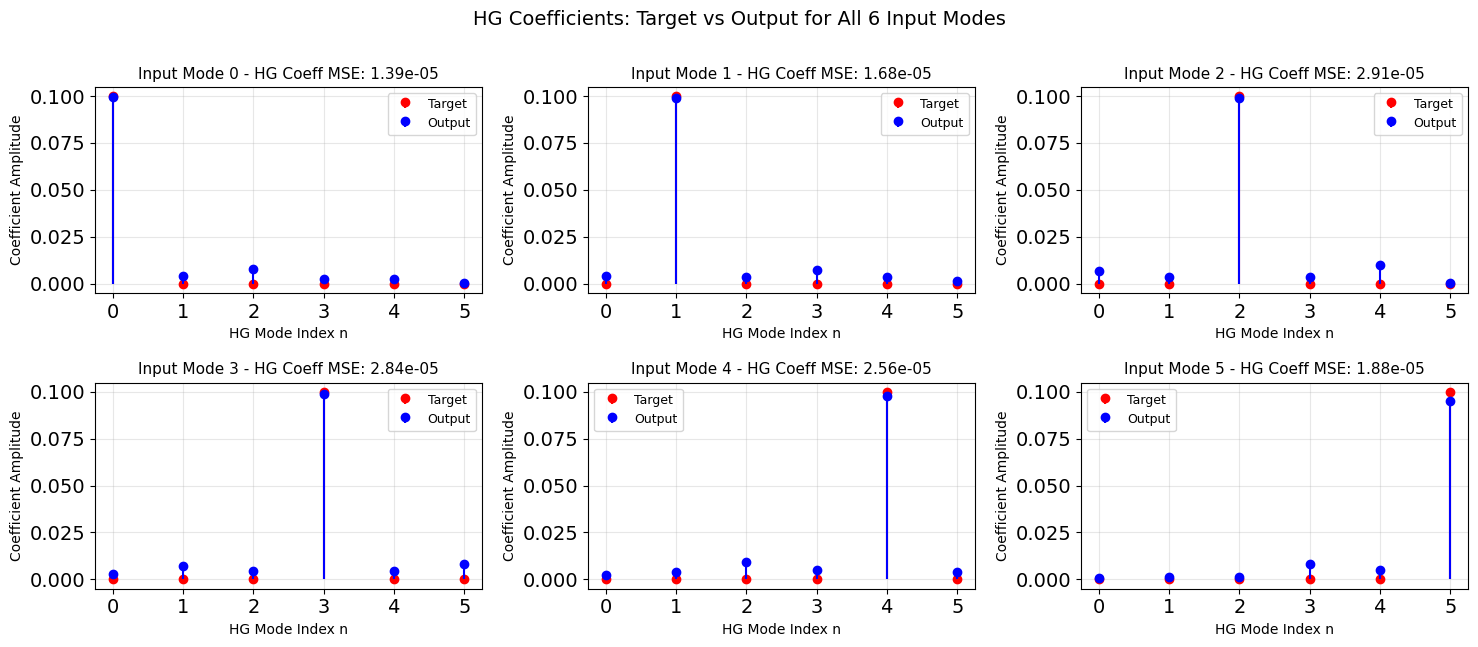

In [9]:
# Plot HG coefficients comparison for all modes
def plot_all_hg_coefficients(A_j_evolution, y, hg_basis_B, dt):
    """Create a grid plot showing HG coefficients for all modes: target vs output."""
    B = y.shape[0]
    
    # Get final outputs and compute HG coefficients
    final_outputs = A_j_evolution[:, :, -1].detach()
    final_j_hg = torch.stack([time_to_hg(final_outputs[i], hg_basis_B, dt) for i in range(B)])
    
    # Compute target HG coefficients
    y_hg_computed = torch.stack([time_to_hg(y[i], hg_basis_B, dt) for i in range(B)])
    
    # Determine grid size
    grid_size = int(np.ceil(np.sqrt(B)))
    
    # Create subplot grid
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(5*grid_size, 3*grid_size))
    if B == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    mode_indices = np.arange(B)
    
    for mode_idx in range(B):
        ax = axes[mode_idx]
        
        # Get coefficients for this mode
        target_coeffs = np.abs(y_hg_computed[mode_idx].detach().cpu().numpy())
        output_coeffs = np.abs(final_j_hg[mode_idx].detach().cpu().numpy())
        
        # Plot as stem plot (like in reference)
        ax.stem(mode_indices, target_coeffs, basefmt=' ', linefmt='r-', markerfmt='ro', label='Target')
        ax.stem(mode_indices, output_coeffs, basefmt=' ', linefmt='b-', markerfmt='bo', label='Output')
        
        # Calculate MSE for HG coefficients
        mse = np.mean((target_coeffs - output_coeffs)**2)
        ax.set_title(f'Input Mode {mode_idx} - HG Coeff MSE: {mse:.2e}', fontsize=11)
        ax.set_xlabel('HG Mode Index n', fontsize=10)
        ax.set_ylabel('Coefficient Amplitude', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    
    # Hide unused subplots
    total_subplots = grid_size * grid_size
    for mode_idx in range(B, total_subplots):
        axes[mode_idx].set_visible(False)
    
    plt.suptitle(f'HG Coefficients: Target vs Output for All {B} Input Modes', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Plot HG coefficients comparison
plot_all_hg_coefficients(A_j_evolution, y, hg_basis_B, dt)


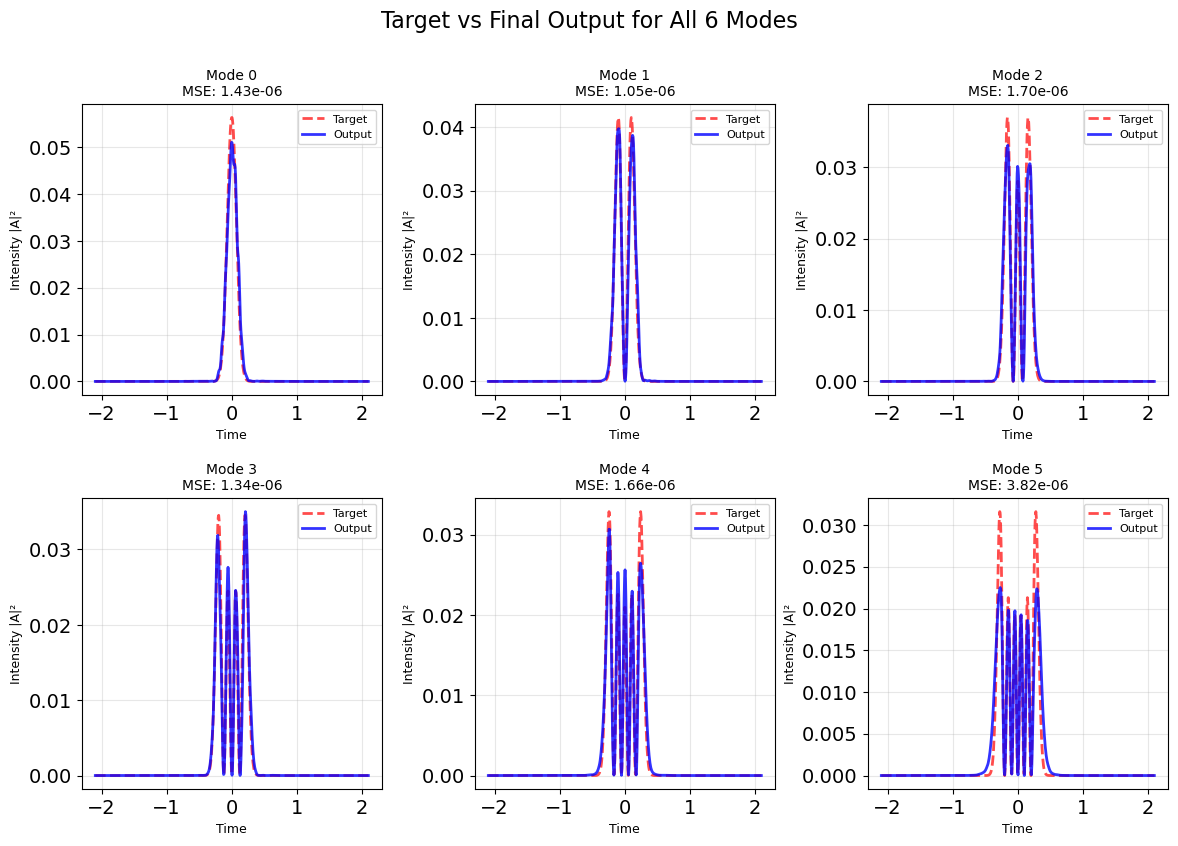

In [10]:
# Plot mode comparison for all training modes
def plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3):
    """Create a grid plot showing all modes: target vs final output."""
    B = y.shape[0]
    
    # Calculate time window for plotting
    total_points = len(t)
    center_points = int(total_points * plot_percent)
    start_idx = (total_points - center_points) // 2
    end_idx = start_idx + center_points
    t_plot = t[start_idx:end_idx].cpu().numpy()
    
    # Get final outputs
    final_outputs = A_j_evolution[:, :, -1].detach()
    
    # Determine grid size (e.g., 2x2 for 4 modes, 4x4 for 16 modes, etc.)
    grid_size = int(np.ceil(np.sqrt(B)))
    
    # Create subplot grid
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(4*grid_size, 4*grid_size))
    if grid_size == 1:
        axes = np.array([[axes]])
    elif grid_size > 1 and B > 1:
        axes = axes.flatten() if axes.ndim == 1 else axes.reshape(-1)
    
    for mode_idx in range(B):
        if grid_size == 1:
            ax = axes[0, 0]
        else:
            ax = axes[mode_idx]
        
        # Extract data for this mode
        target_intensity = np.abs(y[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        output_intensity = np.abs(final_outputs[mode_idx].detach().cpu().numpy())[start_idx:end_idx]**2
        
        # Plot target and output
        ax.plot(t_plot, target_intensity, 'r--', linewidth=2, label='Target', alpha=0.7)
        ax.plot(t_plot, output_intensity, 'b-', linewidth=2, label='Output', alpha=0.8)
        
        # Calculate and display MSE
        mse = np.mean((target_intensity - output_intensity)**2)
        ax.set_title(f'Mode {mode_idx}\nMSE: {mse:.2e}', fontsize=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Intensity |A|²', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots if B is not a perfect square
    total_subplots = grid_size * grid_size
    if B < total_subplots:
        for mode_idx in range(B, total_subplots):
            if grid_size > 1:
                axes[mode_idx].set_visible(False)
    
    plt.suptitle(f'Target vs Final Output for All {B} Modes', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()

# Plot the comparison
plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3)
